# Ocean MultiScale MeshGraph

In this notebook different meshes for the data-driven model under development are explored. The first is the icosahedral multi-mesh used by GraphCast as is, the second is a masked version of the previous, finally, a hierarchical triangle mesh obtained with `seamsh` has been considered.

In future revisions it should include also a display of mesh size fields, including those based on statistics (the one using average SST interpolation error estimate or the one using the Courant condition).

In [1]:
import platform
import pathlib

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray
from geopy.geocoders import Nominatim

from graphcast import mesh_connectivity
from graphcast import mesh_graph
from graphcast import ocean_mesh_utils
from graphcast import plot_utils

In [2]:
save_figures = True

output_dir = pathlib.Path('outputs/multiscale_meshgraph')
if not output_dir.exists():
  output_dir.mkdir(parents=True)

In [3]:
# The zoom-ins will be around the following area.
geolocator = Nominatim(user_agent="multiscale_meshgraph")
location = geolocator.geocode("Rome, Italy")
width, height = 10.0, 10.0
location_lat = location.latitude
location_lon = location.longitude if location.longitude >= 0 else location.longitude + 360.0
bounds = mesh_connectivity.Box(
    lat_min=location_lat - height / 2,
    lat_max=location_lat + height / 2,
    lon_min=location_lon - width / 2,
    lon_max=location_lon + width / 2)
location, bounds

(Location(Roma, Roma Capitale, Lazio, Italia, (41.8933203, 12.4829321, 0.0)),
 Box(lat_min=36.8933203, lat_max=46.8933203, lon_min=7.482932099999999, lon_max=17.4829321))

In [4]:
if platform.node().endswith('leonardo.local'):
    data_dir = pathlib.Path("/leonardo_scratch/large/userexternal/scampane/xcast/data")
else:
    data_dir = pathlib.Path("../data")

In [5]:
dataset = xarray.open_dataset(data_dir / 'dataset/dataset_tres-1d_res-0p25_levels-10_arco', engine='zarr')
dataset

<xarray.Dataset> Size: 2GB
Dimensions:         (time: 7, lat: 721, lon: 1440, level: 10)
Coordinates:
    depth           (level) float32 40B ...
  * lat             (lat) float32 3kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * level           (level) int64 80B 0 4 8 12 16 20 24 28 32 34
  * lon             (lon) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time            (time) datetime64[ns] 56B 2000-01-01 ... 2000-01-07
Data variables: (12/33)
    10u             (time, lat, lon) float32 29MB ...
    10v             (time, lat, lon) float32 29MB ...
    2d              (time, lat, lon) float32 29MB ...
    2t              (time, lat, lon) float32 29MB ...
    deptho          (lat, lon) float32 4MB ...
    dis24           (time, lat, lon) float32 29MB ...
    ...              ...
    vsd             (time, lat, lon) float32 29MB ...
    vsi             (time, lat, lon) float32 29MB ...
    waverys_deptho  (lat, lon) float32 4MB ...
    waverys_mask    (lat, lon) bool 1MB ...
    z               (lat, lon) float32 4MB ...
    zos             (time, lat, lon) float32 29MB ...
Attributes:
    last_updated:           2025-07-17 01:52:23.900829+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-04-30
    valid_time_stop_era5t:  2025-07-11

## Cartesian Grids

In [6]:
# TODO: IMPORTANT! CHECK GRID CONNECTIVITY FUNCTIONS!

In [7]:
mask = dataset['glorys_mask'].isel(level=0, drop=True)

grid_lat, grid_lon = np.meshgrid(mask['lat'], mask['lon'], indexing='ij')
masked_grid_lat = grid_lat[mask.astype(bool)]
masked_grid_lon = grid_lon[mask.astype(bool)]

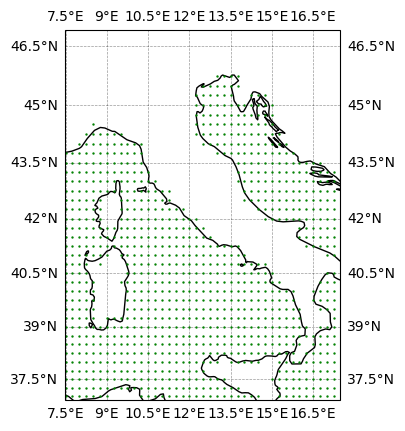

In [8]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.set_extent([bounds.lon_min, bounds.lon_max, bounds.lat_min, bounds.lat_max])
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '50m', edgecolor='black', facecolor='never'))
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.4, color='k', linestyle='--')

ax.scatter(masked_grid_lon, masked_grid_lat, marker='.', color="green", s=2.0, zorder=2, transform=ccrs.PlateCarree())

if save_figures:
  plt.savefig(output_dir / 'grid_res-0.25_zoomin.png', bbox_inches='tight')

## Hierarchical Triangle Mesh

In [9]:
coarse_mesh, coarse_boundary = ocean_mesh_utils.read_mesh(data_dir / 'geometry/uniform_coarse.msh')
coarse_mesh_within_box, coarse_within_box_mapping = mesh_connectivity.get_mesh_within_box(coarse_mesh, bounds)
coarse_boundary_within_box = np.array([coarse_within_box_mapping[n] for n in coarse_boundary if n in coarse_within_box_mapping])
coarse_mesh_graph_within_box = mesh_graph.mesh_to_latlon(coarse_mesh_within_box)

In [ ]:
fine_mesh, fine_boundary = ocean_mesh_utils.read_mesh(data_dir / 'geometry/uniform_fine.msh')
fine_mesh_within_box, fine_within_box_mapping = mesh_connectivity.get_mesh_within_box(fine_mesh, bounds)
fine_boundary_within_box = np.array([fine_within_box_mapping[n] for n in fine_boundary if n in fine_within_box_mapping])
fine_mesh_graph_within_box = mesh_graph.mesh_to_latlon(fine_mesh_within_box)

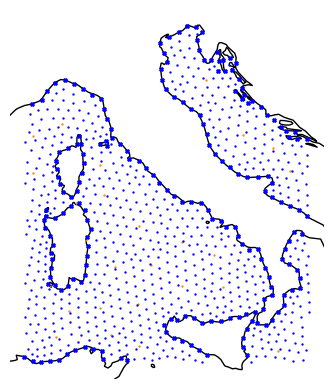

In [10]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '50m', edgecolor='black', facecolor='never'))

latitudes, longitudes = coarse_mesh_graph_within_box.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", s=2.0, zorder=2, transform=ccrs.PlateCarree())

latitudes, longitudes = fine_mesh_graph_within_box.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", s=2.0, zorder=2, transform=ccrs.PlateCarree())

if fine_boundary_within_box.size > 0:
    latitudes, longitudes = [fine_mesh_graph_within_box.vertices[i][fine_boundary_within_box] for i in [0, 1]]
    ax.scatter(longitudes, latitudes, marker='X', color="blue", s=6.0, zorder=2, transform=ccrs.PlateCarree())

if save_figures:
  plt.savefig(output_dir / 'latent_representation.png', bbox_inches='tight')

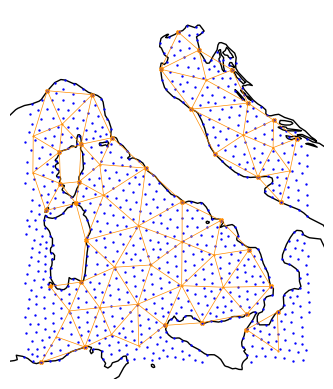

In [11]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '50m', edgecolor='black', facecolor='never'))

# Add coarse mesh vertices
latitudes, longitudes = coarse_mesh_graph_within_box.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", s=1.0, zorder=2, transform=ccrs.PlateCarree())

# Add coarse mesh boundary vertices
if coarse_boundary_within_box.size > 0:
    latitudes, longitudes = [coarse_mesh_graph_within_box.vertices[i][coarse_boundary_within_box] for i in [0, 1]]
    ax.scatter(longitudes, latitudes, marker='X', color="darkorange", s=6.0, zorder=2, transform=ccrs.PlateCarree())

# Add fine mesh vertices
latitudes, longitudes = fine_mesh_graph_within_box.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add coarse mesh edges
lc = plot_utils.get_line_collection(coarse_mesh_graph_within_box, linewidths=0.5, colors="darkorange", transform=ccrs.Geodetic())
ax.add_collection(lc)

if save_figures:
  plt.savefig(output_dir / 'coarse_meshgraph.png', bbox_inches='tight')


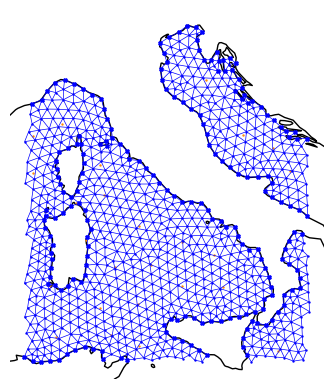

In [12]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '50m', edgecolor='black', facecolor='never'))

# Add coarse mesh vertices
latitudes, longitudes = coarse_mesh_graph_within_box.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add fine mesh vertices
latitudes, longitudes = fine_mesh_graph_within_box.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add fine mesh boundary vertices
if fine_boundary_within_box.size > 0:
    latitudes, longitudes = [fine_mesh_graph_within_box.vertices[i][fine_boundary_within_box] for i in [0, 1]]
    ax.scatter(longitudes, latitudes, marker='X', color="blue", s=6.0, zorder=2, transform=ccrs.PlateCarree())

# Add fine mesh edges
lc = plot_utils.get_line_collection(fine_mesh_graph_within_box, linewidths=0.5, colors="blue", transform=ccrs.Geodetic())
ax.add_collection(lc)

if save_figures:
    plt.savefig(output_dir / 'fine_meshgraph.png', bbox_inches='tight')

In [13]:
dummy_multiscale_typed_graph = mesh_connectivity.get_dummy_xscaling_graph(coarse_mesh_within_box, fine_mesh_within_box, name_a="coarse", name_b="fine")

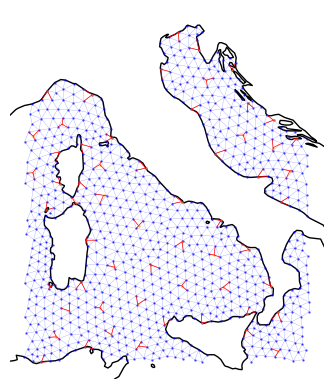

In [14]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '50m', edgecolor='black', facecolor='never'))

# Add fine mesh vertices
latitudes, longitudes = fine_mesh_graph_within_box.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", alpha=0.6, s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add fine mesh edges with alpha
lc = plot_utils.get_line_collection(fine_mesh_graph_within_box, linewidths=0.16, colors="blue", alpha=0.6, transform=ccrs.Geodetic())
ax.add_collection(lc)

# Add coarse mesh vertices
latitudes, longitudes = coarse_mesh_graph_within_box.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", alpha=0.6, s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add downsampling ("fine2coarse") edges
downsampling_wgs_graph = mesh_graph.typed_to_latlon(dummy_multiscale_typed_graph, edge_set_name="fine_to_coarse")
lc = plot_utils.get_line_collection(downsampling_wgs_graph, linewidths=0.5, colors="red", transform=ccrs.Geodetic())
ax.add_collection(lc)

if save_figures:
  plt.savefig(output_dir / 'downsample.png', bbox_inches='tight')


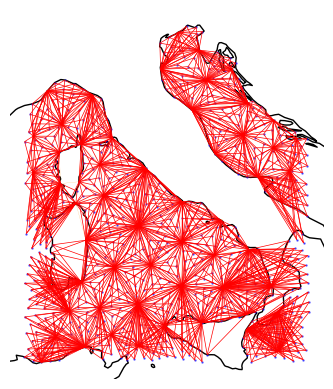

In [15]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '50m', edgecolor='black', facecolor='never'))

# Add coarse mesh vertices
lc = plot_utils.get_line_collection(coarse_mesh_graph_within_box, linewidths=0.16, colors="darkorange", alpha=0.6, transform=ccrs.Geodetic())
ax.add_collection(lc)

# Add coarse mesh edges with alpha
latitudes, longitudes = coarse_mesh_graph_within_box.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", alpha=0.6, s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Plot fine mesh vertices
latitudes, longitudes = fine_mesh_graph_within_box.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", alpha=0.6, s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add downsampling ("fine2coarse") edges
downsampling_wgs_graph = mesh_graph.typed_to_latlon(dummy_multiscale_typed_graph, edge_set_name="coarse_to_fine")
lc = plot_utils.get_line_collection(downsampling_wgs_graph, linewidths=0.5, colors="red", transform=ccrs.Geodetic())
ax.add_collection(lc)

if save_figures:
  plt.savefig(output_dir / 'upsample.png', bbox_inches='tight')
